1) **Basic Overview**
   - Shape (rows, columns
   - Data types (int, float, object, datetime
   - Preview (head, tail)

3) **Data Quality Checks**
   - Missing values (count + % per column)
   - Duplicates
   - Invalid values (e.g. negative ages, impossible dates)
   - Consistency (e.g. mixed formats in same column)
     
4) **Univariate Analysis (one variable at a time)**

   Numerical features:
   - Mean, median, std
   - Min / max
   - Distribution (histogram, KDE)
   - Outliers (boxplot)

   Categorical features:
   - Value counts
   - Frequency (%)
   - Rare categories
     
5) **Bivariate Analysis (relationships)**

   Numeric vs Numeric:
   - Scatter plots
   - Correlation (Pearson/Spearman)
     
   Categorical vs Numeric:
   - Grouped stats (mean target per category)
   - Boxplots
     
   Categorical vs Categorical:
   - Crosstab
   - Heatmaps
     

6) **Target Variable Analysis**

   Distribution of target
   - Imbalance (classification)
   - Outliers (regression)
   - Relationship with features

7) **Correlation & Multicollinearity**

   - Correlation matrix
   - Highly correlated features
   - Redundant variables
     
8) **Outliers Analysis**

   - Detect (IQR / Z-score / visual)
   - Understand: error or real signal?
   - Decide: keep / cap / remove

9) **Time-Based Analysis**

    - Trends over time
    - Aggregations (hours)
      
10) **Insights & desicions**



# Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Imports

In [6]:
df = pd.read_csv(r'../data/interim_data/telaviv_buses_0704_1304_2024_cleaned_new_features.csv',encoding='utf-8-sig')

# 1. Basic Overview

In [8]:
### Df shape
df.shape

(92548, 37)

In [14]:
### Preview
df.head(5)

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,line_num_agency_alter_dir,urban,route_dir_alt_day_hr,Total_Passengers,Avg_Passengers_Per_Bus
0,2024-04-07,Sunday,0,826,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ד...,15123,10826,1,9,Egged,...,0.0,30946.992877,128214.134588,24.14,1.409145,Egged_826_1,False,10826_1_9_Sunday_0,1.0,1.0
1,2024-04-07,Sunday,0,61,מסוף עמידר-רמת גן<->מסוף כרמלית/הורדה-תל אביב ...,2512,16061,2,0,Dan,...,0.0,2595.473725,12742.652985,20.37,1.841781,Dan_61_2,False,16061_2_0_Sunday_0,13.0,6.5
2,2024-04-07,Sunday,0,63,הכובשים/דניאל-תל אביב יפו<->מסוף אלוף שדה-רמת ...,2517,17063,1,0,Dan,...,0.0,2833.152306,12232.226796,23.16,1.842028,Dan_63_1,False,17063_1_0_Sunday_0,9.0,9.0
3,2024-04-07,Sunday,0,70,ת.רכבת תל אביב - סבידור/רציפים C-תל אביב יפו<-...,2542,20070,1,0,Dan,...,0.0,4872.654308,10968.248411,44.43,1.791541,Dan_70_1,False,20070_1_0_Sunday_0,5.0,5.0
4,2024-04-07,Sunday,0,66,ת. מרכזית פ''ת/רציפים-פתח תקווה<->מסוף כרמלית/...,2532,15066,1,0,Dan,...,0.0,7989.261100,16464.450441,48.52,1.394338,Dan_66_1,False,15066_1_0_Sunday_0,12.0,12.0


In [13]:
### Data types
df.dtypes


date                          object
day                           object
hour_rounded                   int64
line_num                      object
line_name                     object
route_id                       int64
route_mkt                      int64
direction                      int64
alternative                   object
agency_name                   object
route_type                    object
origin_city                   object
origin_station                object
destination_city              object
destination_station           object
number_of_stops                int64
route_length_km              float64
departure_time_planned        object
arrival_time_planned          object
duration_min_planned         float64
duration_min_actual          float64
duration_difference_min      float64
speed_kmh_planned            float64
speed_kmh_actual             float64
gtfs_route_id                  int64
gtfs_ride_id                   int64
SIRI_id                        int64
r

# 2) Data Quality Checks

## Missing values

In [20]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
duration_difference_min,19624,21.204132
duration_min_planned,19573,21.149025
speed_kmh_planned,19573,21.149025
Avg_Passengers_Per_Bus,2208,2.385789
Total_Passengers,2208,2.385789
length_in_buffer_m,1128,1.218827
curvity,1128,1.218827
perc_within_pt_route,1128,1.218827
route_length,1128,1.218827
agency_name,185,0.199896


## Duplicates

In [21]:
df.duplicated().sum()

np.int64(0)

## Invalid values

The following validation checks were applied to assess data quality:

- `date` — invalid date values after converting from string to datetime
- `hour` — values smaller than 0 or larger than 23
- `number_of_stops` — values smaller than or equal to 0
- `route_length_km` — values smaller than or equal to 0
- `rainfall_mm` — negative values
- `length_in_buffer_m` — negative values
- `duration_min_planned` — values smaller than or equal to 0
- `duration_min_actual` — values smaller than or equal to 0
- `route_length` — values smaller than or equal to 0
- `perc_within_pt_route` — negative values
- `curvity` — values smaller than 1
- `Total_Passengers` — negative values
- `Avg_Passengers_Per_Bus` — negative values

In [26]:
# Copy dataframe if you want to avoid changing the original
df_checked = df.copy()

# Convert date column from string to datetime
# Invalid parsing will become NaT
df_checked['date_converted'] = pd.to_datetime(df_checked['date'], errors='coerce')

# Define invalid value checks
checks = {
    'date_invalid': df_checked['date_converted'].isna(),
    'hour_invalid': (df_checked['hour_rounded'] < 0) | (df_checked['hour_rounded'] > 23),
    'number_of_stops_invalid': df_checked['number_of_stops'] <= 0,
    'route_length_km_invalid': df_checked['route_length_km'] <= 0,
    'rainfall_mm_invalid': df_checked['rainfall_mm'] < 0,
    'length_in_buffer_m_invalid': df_checked['length_in_buffer_m'] < 0,
    'duration_min_planned_invalid': df_checked['duration_min_planned'] <= 0,
    'duration_min_actual_invalid': df_checked['duration_min_actual'] <= 0,
    'route_length_invalid': df_checked['route_length'] <= 0,
    'perc_within_pt_route_invalid': df_checked['perc_within_pt_route'] < 0,
    'curvity_invalid': df_checked['curvity'] < 1,
    'Total_Passengers_invalid': df_checked['Total_Passengers'] < 0,
    'Avg_Passengers_Per_Bus_invalid': df_checked['Avg_Passengers_Per_Bus'] < 0
}

# Build summary table
invalid_summary = pd.DataFrame({
    'Check': list(checks.keys()),
    'Invalid Count': [condition.sum() for condition in checks.values()],
    'Invalid %': [condition.mean() * 100 for condition in checks.values()]
})

invalid_summary['Invalid %'] = invalid_summary['Invalid %'].round(2)

invalid_summary = invalid_summary.sort_values('Invalid %', ascending=False).reset_index(drop=True)

invalid_summary

,Check,Invalid Count,Invalid %
0,date_invalid,0,0.0
1,hour_invalid,0,0.0
2,number_of_stops_invalid,0,0.0
3,route_length_km_invalid,0,0.0
4,rainfall_mm_invalid,0,0.0
5,length_in_buffer_m_invalid,0,0.0
6,duration_min_planned_invalid,0,0.0
7,duration_min_actual_invalid,0,0.0
8,route_length_invalid,0,0.0
9,perc_within_pt_route_invalid,0,0.0


## Consistency

In [29]:
consistency_overview = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique(),
    'sample_values': df.apply(lambda x: x.dropna().astype(str).unique()[:3])
})

consistency_overview

,dtype,unique_values,sample_values
date,object,7,"[2024-04-07, 2024-04-08, 2024-04-09]"
day,object,7,"[Sunday, Monday, Tuesday]"
hour_rounded,int64,24,"[0, 1, 2]"
line_num,object,298,"[826, 61, 63]"
line_name,object,631,[ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->...
route_id,int64,715,"[15123, 2512, 2517]"
route_mkt,int64,305,"[10826, 16061, 17063]"
direction,int64,3,"[1, 2, 3]"
alternative,object,30,"[9, 0, #]"
agency_name,object,10,"[Egged, Dan, Metropolin]"


# 3) Univariate Analysis

In [34]:
### splitting to numeric and categorial columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

## Numeric columns

In [35]:
### Summary statistics

num_summary = df[numeric_cols].describe().T

num_summary = num_summary[['mean', '50%', 'std', 'min', 'max']]
num_summary = num_summary.rename(columns={'50%': 'median'})

num_summary

,mean,median,std,min,max
hour_rounded,1.282100e+01,1.300000e+01,5.229215,0.000000e+00,2.300000e+01
route_id,1.149116e+04,9.780000e+03,10325.973620,3.900000e+01,3.834300e+04
route_mkt,1.999235e+04,1.504200e+04,15189.293952,1.011200e+04,9.900200e+04
direction,1.496078e+00,1.000000e+00,0.512832,1.000000e+00,3.000000e+00
number_of_stops,3.931763e+01,4.000000e+01,13.075301,2.000000e+00,1.070000e+02
route_length_km,2.429382e+01,1.787900e+01,24.520324,3.190000e+00,3.213640e+02
duration_min_planned,5.496917e+01,5.100000e+01,22.353786,1.900000e+01,3.320000e+02
duration_min_actual,7.148461e+01,6.900000e+01,36.331133,1.000000e+00,1.105000e+03
duration_difference_min,1.669561e+01,1.700000e+01,33.262709,-2.530000e+02,1.076000e+03
speed_kmh_planned,2.469586e+01,1.930000e+01,11.662990,7.500000e+00,7.980000e+01


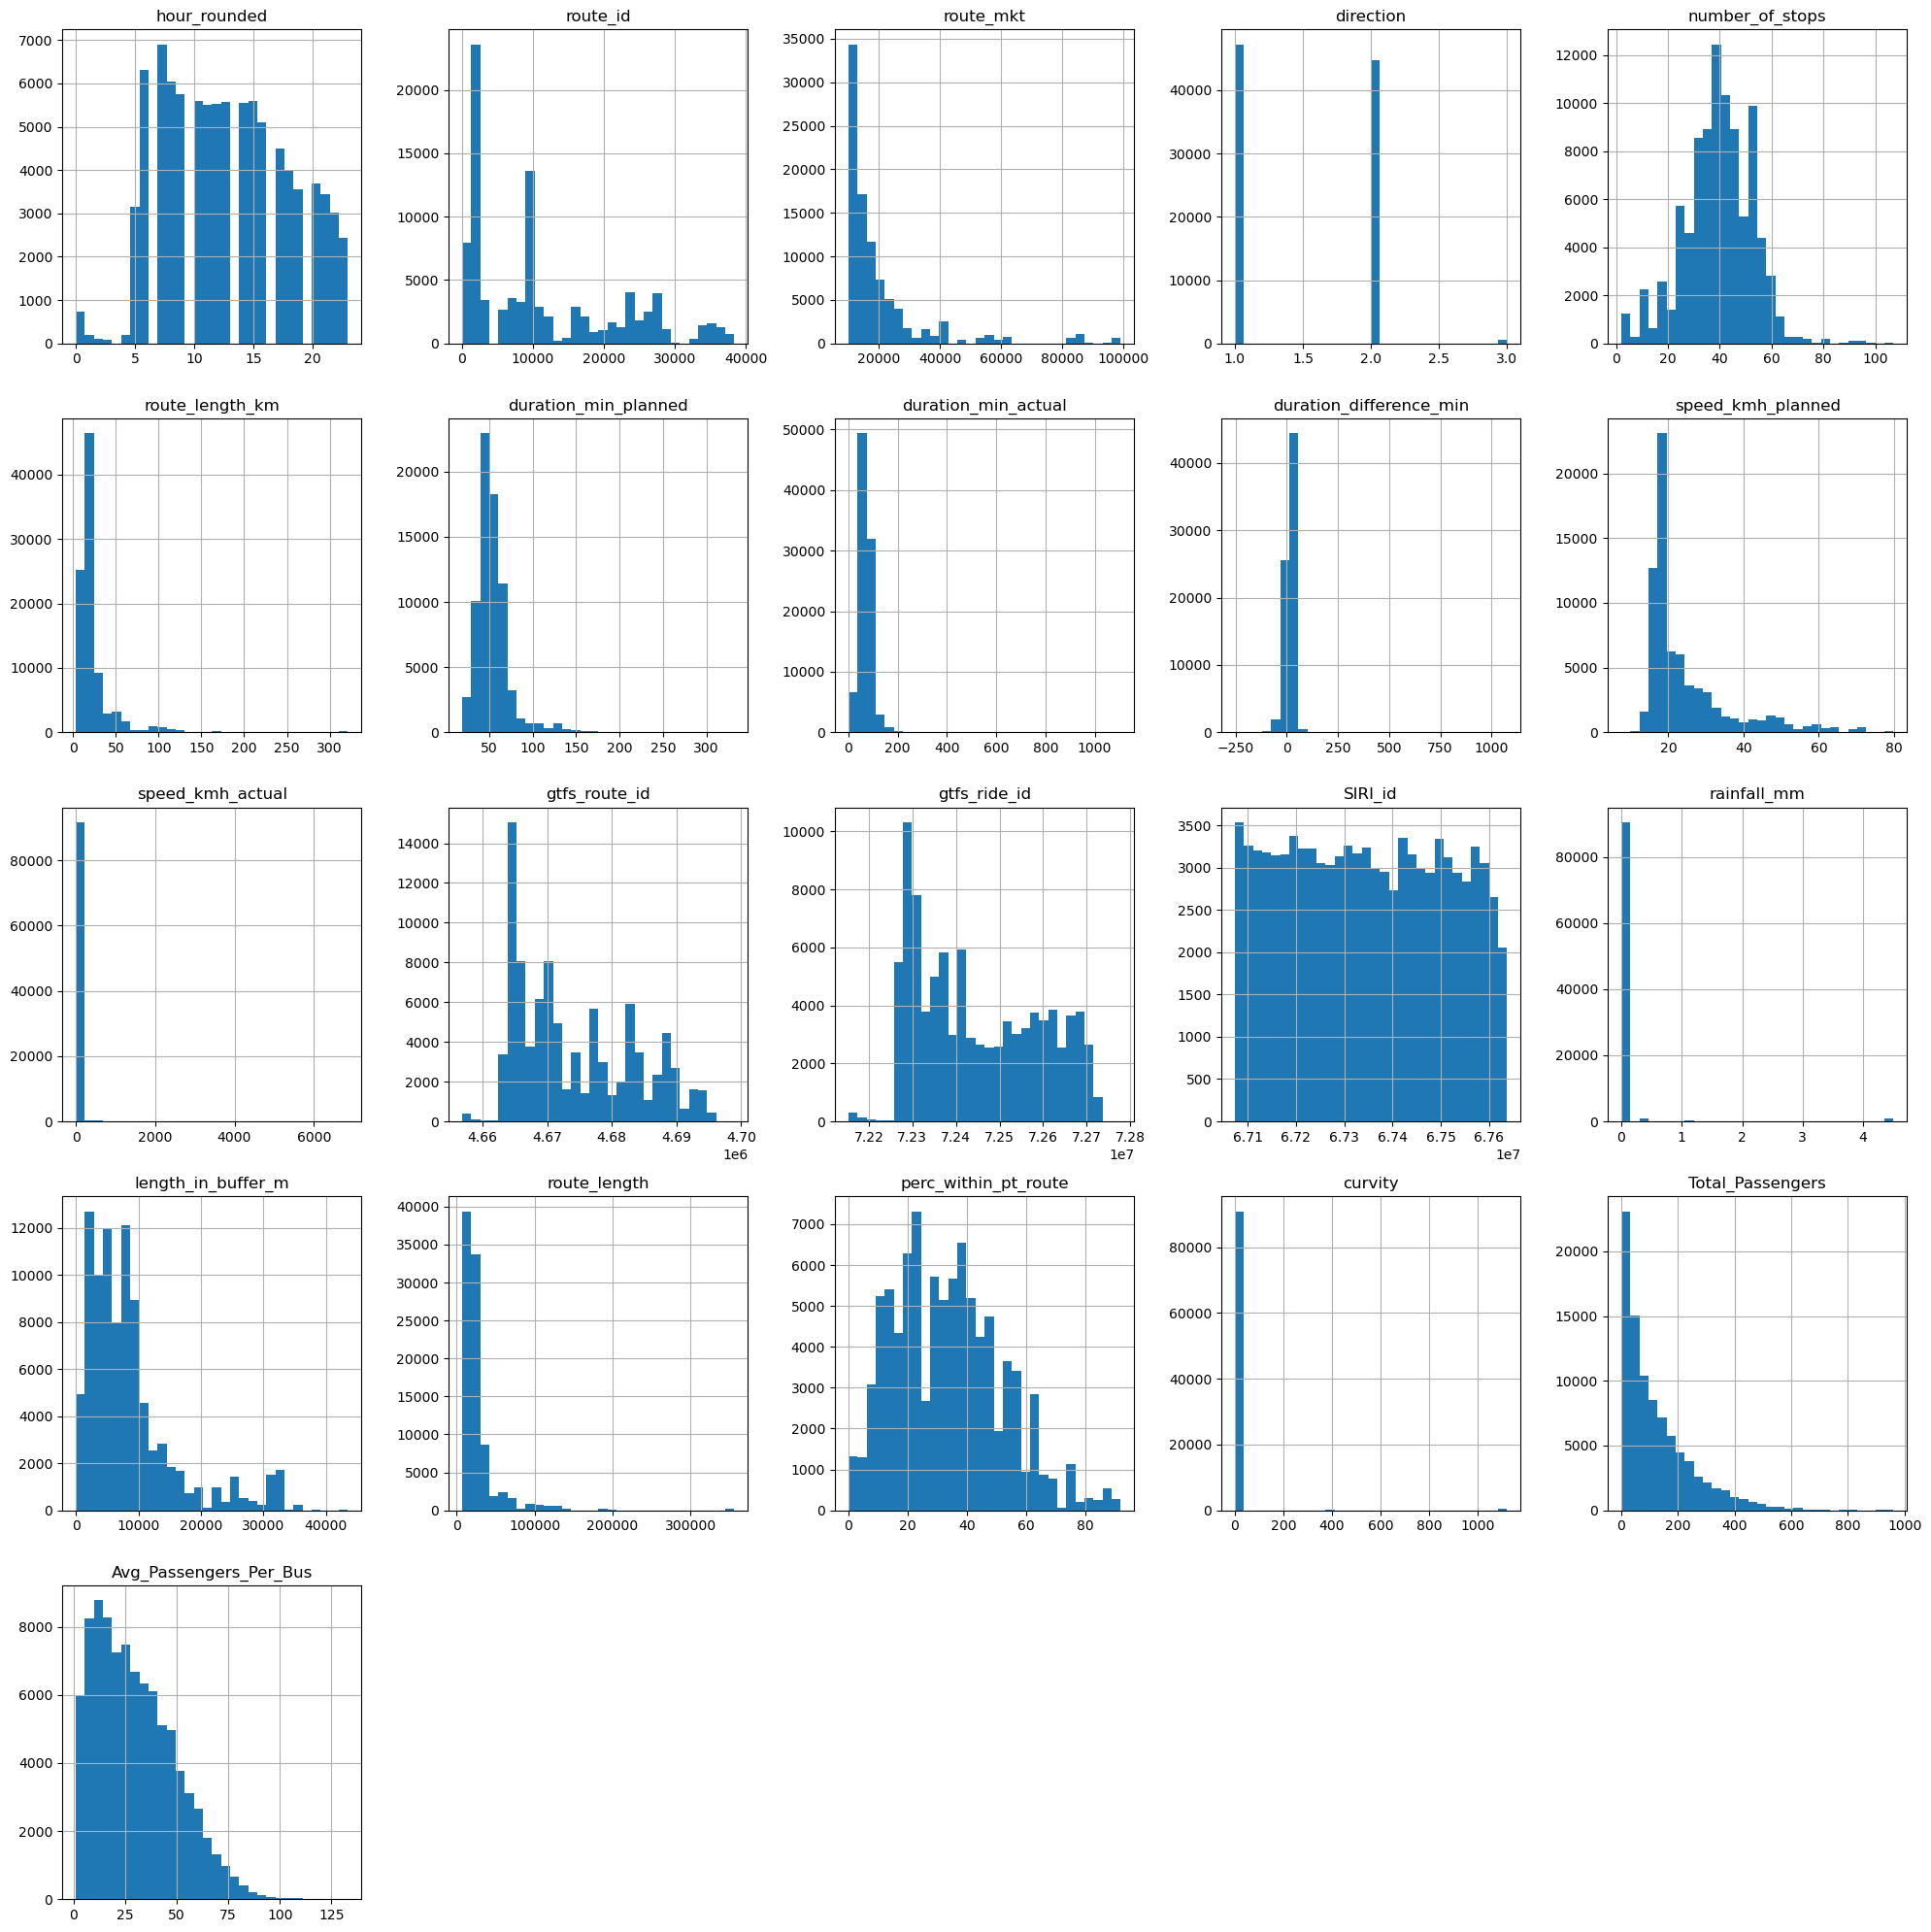

In [44]:
import matplotlib.pyplot as plt
import math

cols = numeric_cols
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].dropna().hist(ax=axes[i], bins=30)
    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

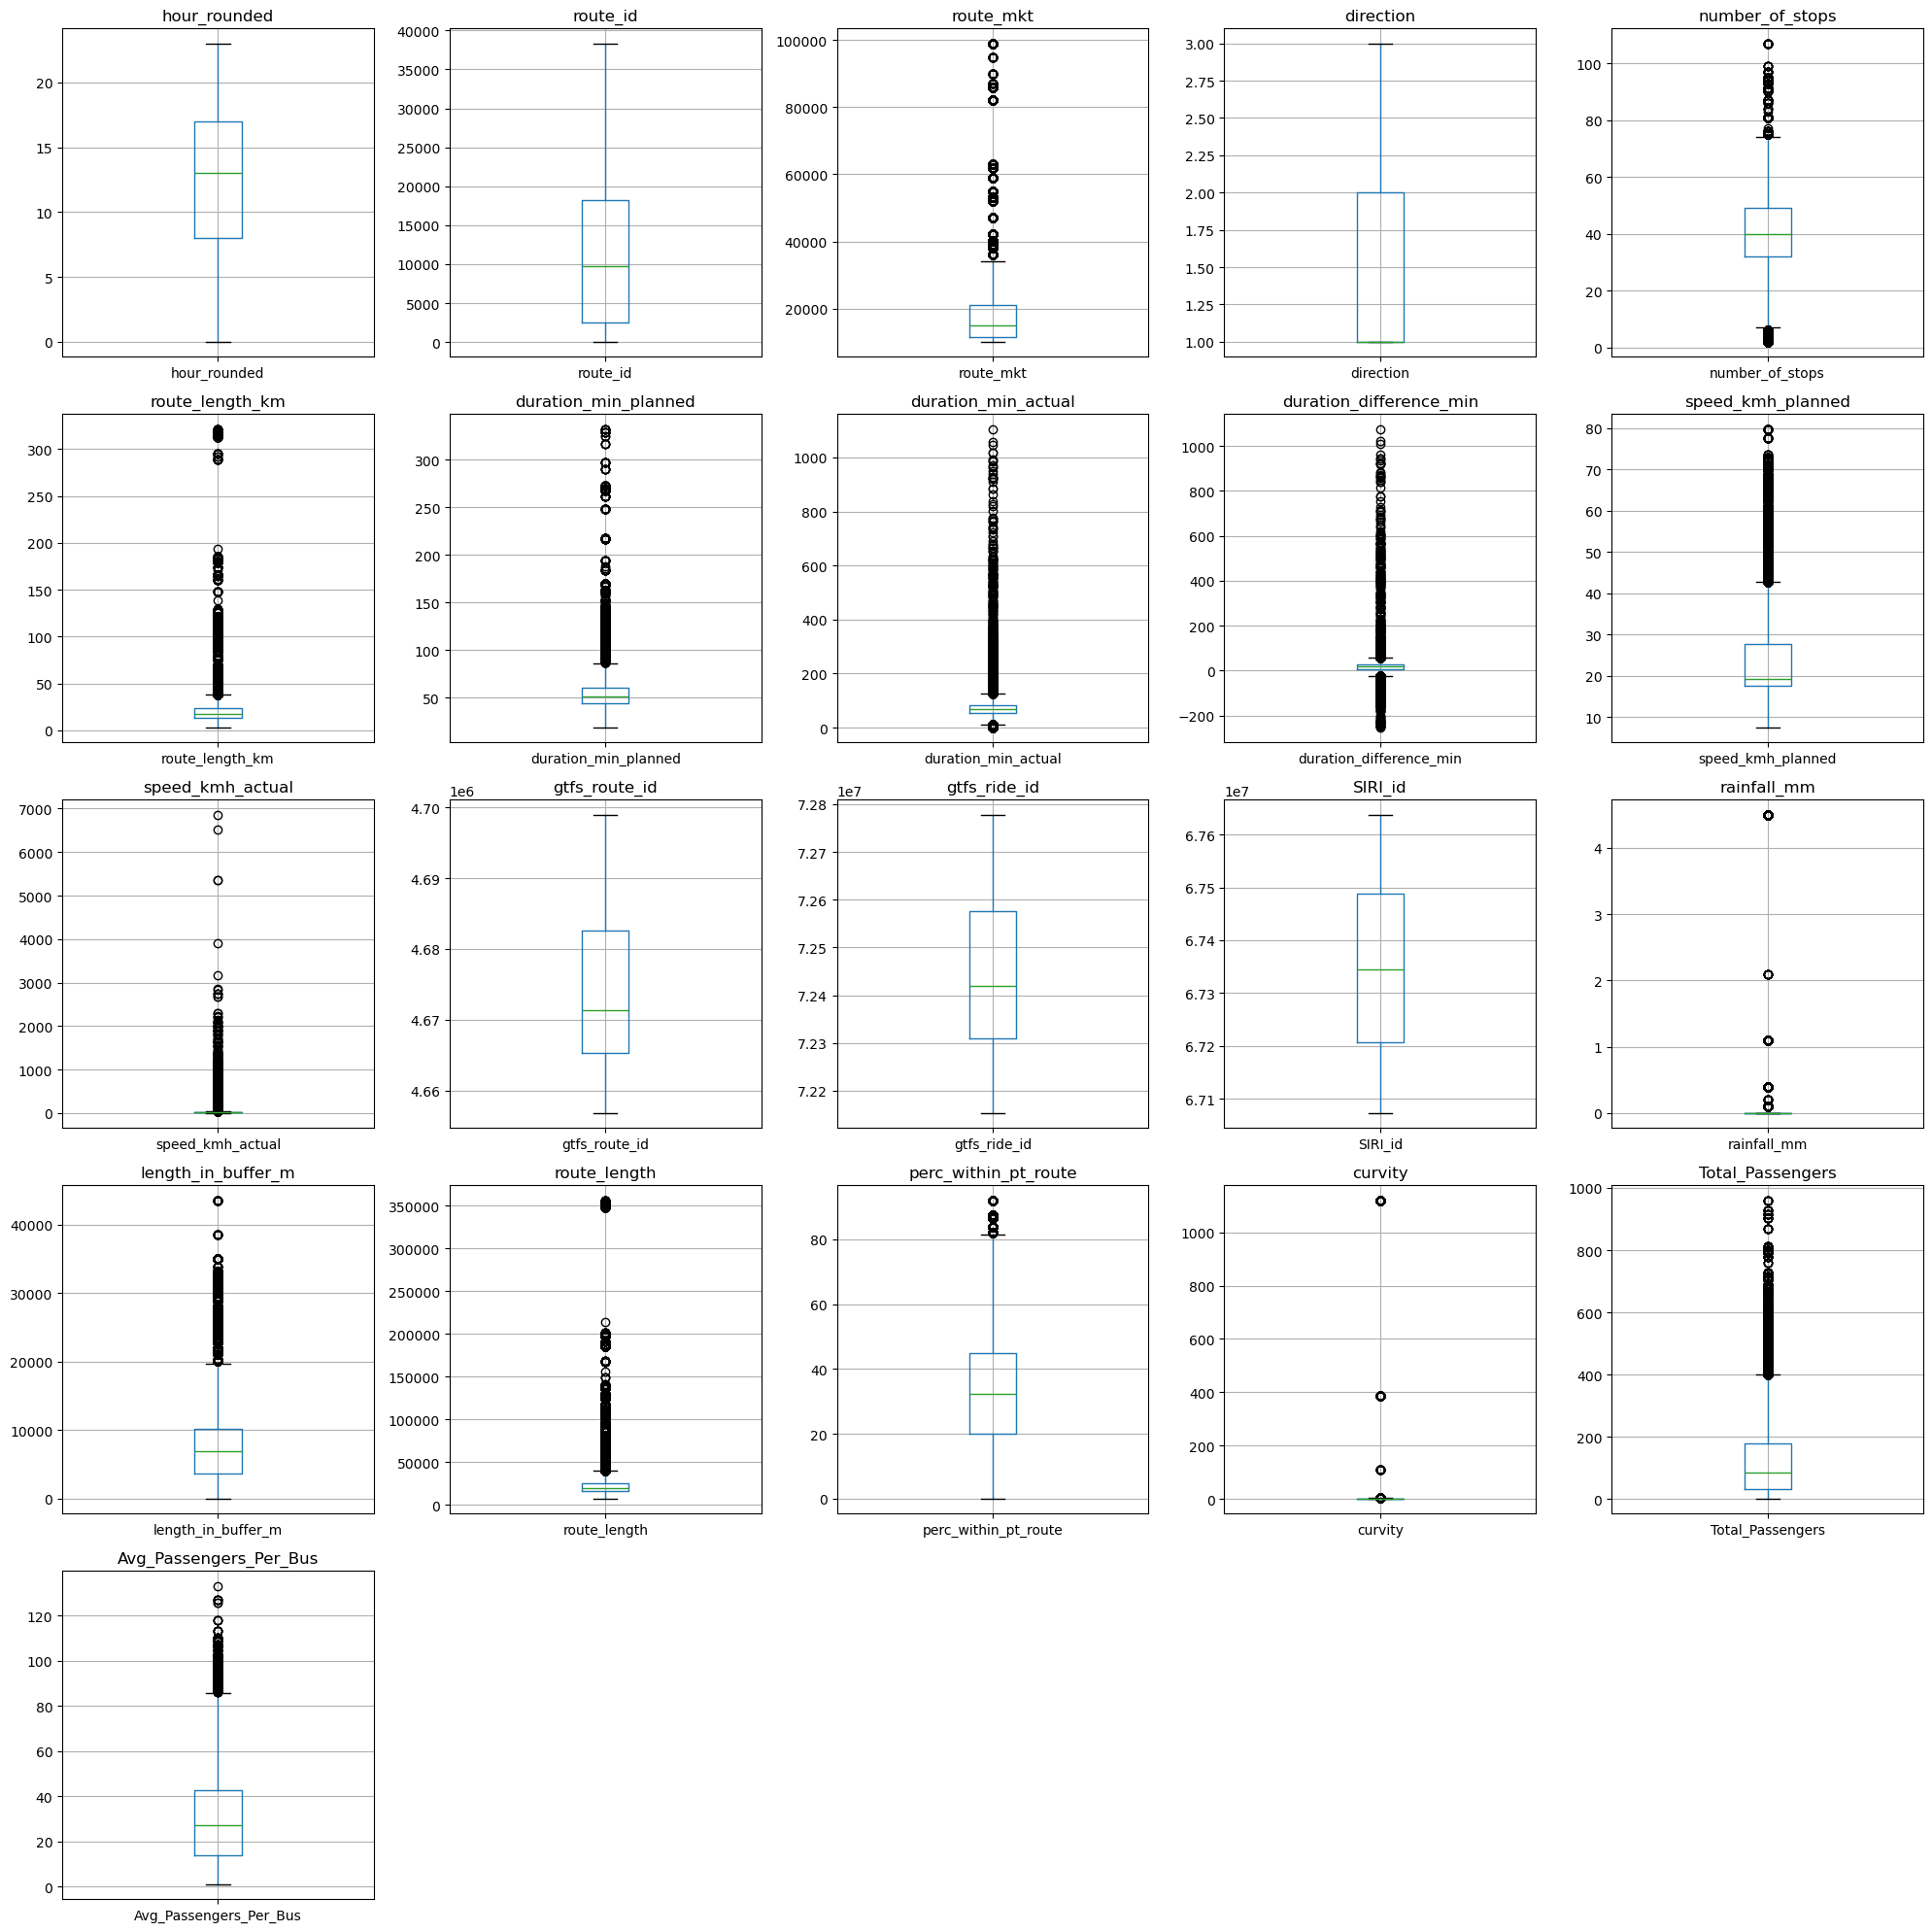

In [45]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorial

C:\Users\shaha\AppData\Local\Temp\ipykernel_9324\871371952.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


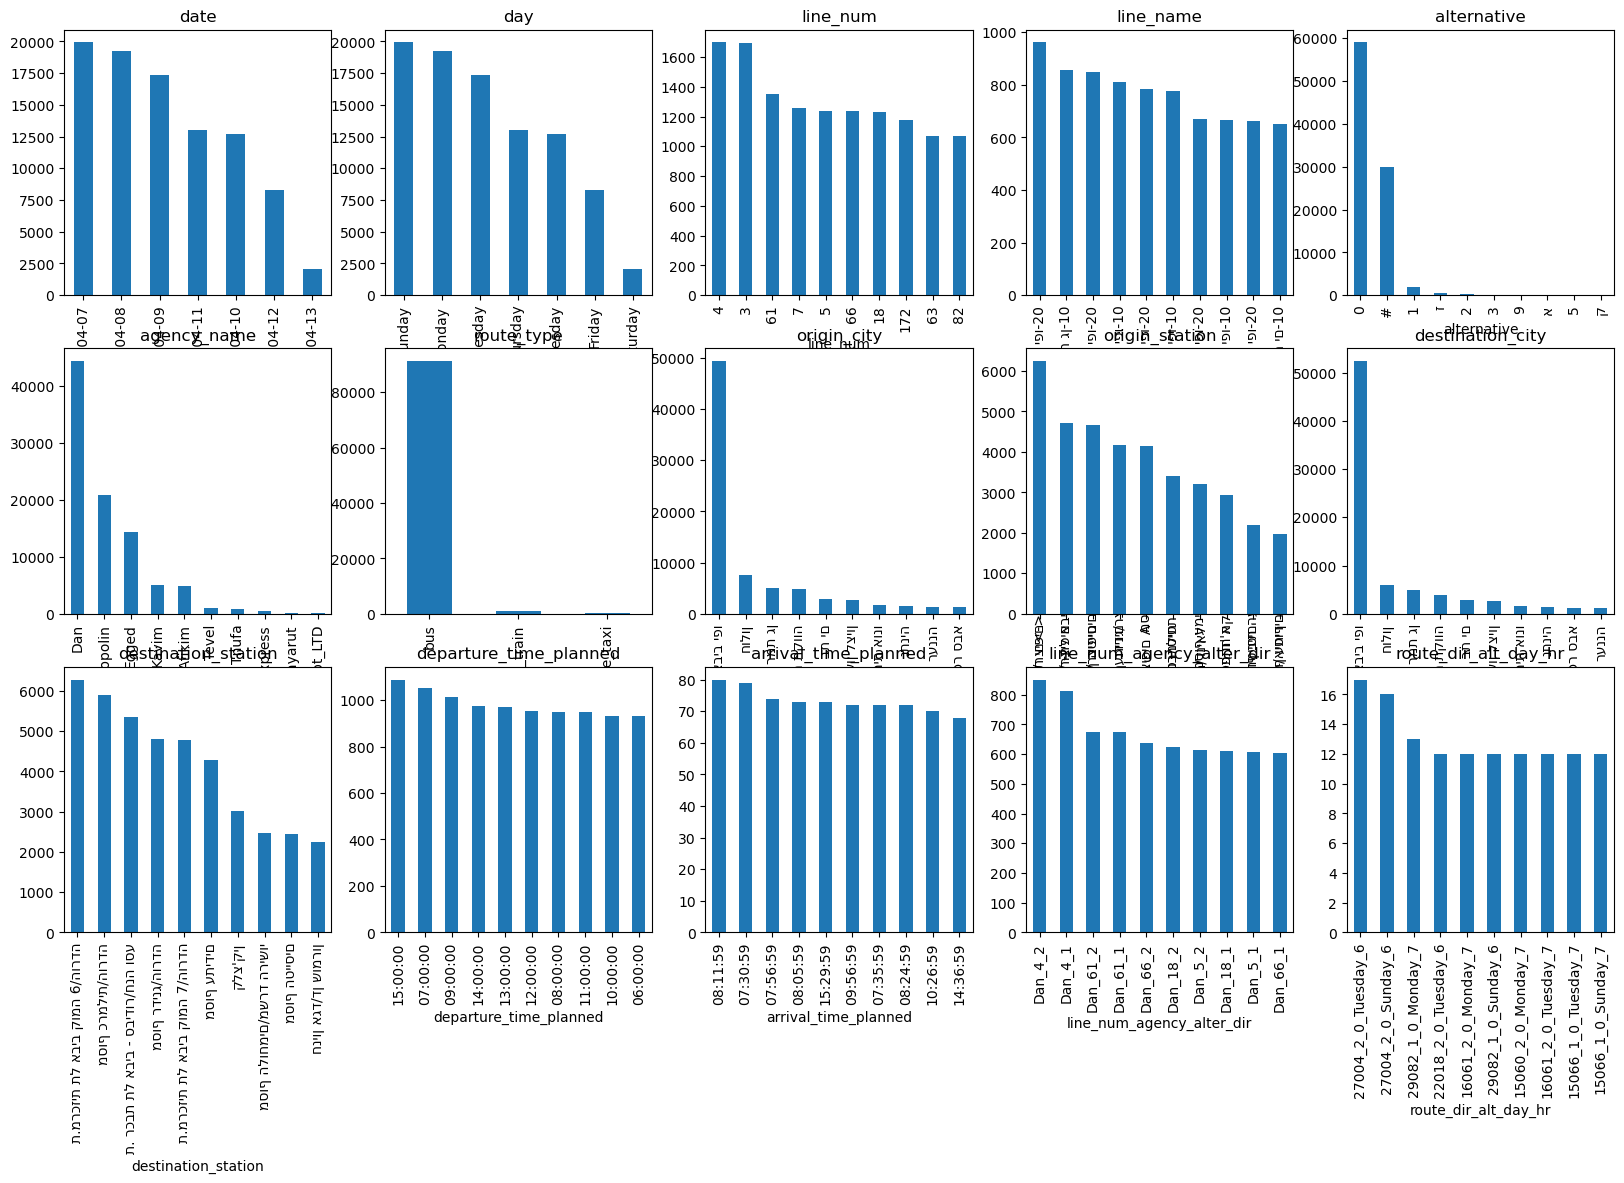

In [51]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()